## 3 – Độ đo Khoảng cách & Phát hiện Outliers

> Trong bài lab này, chúng ta **không thể biết** các tham số thực của quần thể ($\mu$, $\sigma^2$, $\Sigma$).
> Giải pháp: dùng **ước lượng từ toàn bộ tập dữ liệu** thay thế:
> - $\hat{\mu}_k = \bar{x}_k$ (trung bình mẫu)
> - $\hat{\sigma}_k^2 = s_k^2$ (phương sai mẫu, ddof=1 vì n lớn → xấp xỉ tốt)
> - $\hat{\Sigma} = S$ (ma trận hiệp phương sai mẫu)

### a. Ước lượng tham số quần thể

In [5]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

sys.path.append(os.path.abspath('..'))
from helper.utils import (mean, standard_deviation, euclidean_distance, statistical_distance, mahalanobis_distance, mahalanobis_all_samples)
from helper.visualization import contribution_bar

df = pd.read_csv('../data/winequality-red.csv', sep=';')
features = df.drop(columns=['quality'])
var_list = features.columns.tolist()
n, p = features.shape

sample_mean = np.array([mean(features[col]) for col in var_list])
sample_std  = np.array([standard_deviation(features[col], is_population=True) for col in var_list])
sample_var = sample_std ** 2

desc = pd.DataFrame({
    "mean": sample_mean,
    "std": sample_std,
    "var": sample_var,
    "min": features.min().values,
    "max": features.max().values
}, index=var_list).round(2)

print(f"p = {len(var_list)} biến")
print(f"n = {len(features)} mẫu\n")

print(f'Ước lượng của quần thể:\n {desc}')

p = 11 biến
n = 1599 mẫu

Ước lượng của quần thể:
                        mean    std      var   min     max
fixed acidity          8.32   1.74     3.03  4.60   15.90
volatile acidity       0.53   0.18     0.03  0.12    1.58
citric acid            0.27   0.19     0.04  0.00    1.00
residual sugar         2.54   1.41     1.99  0.90   15.50
chlorides              0.09   0.05     0.00  0.01    0.61
free sulfur dioxide   15.87  10.46   109.35  1.00   72.00
total sulfur dioxide  46.47  32.89  1081.43  6.00  289.00
density                1.00   0.00     0.00  0.99    1.00
pH                     3.31   0.15     0.02  2.74    4.01
sulphates              0.66   0.17     0.03  0.33    2.00
alcohol               10.42   1.07     1.13  8.40   14.90


### Nhận xét dữ liệu

| Nhóm biến | Đặc điểm | 
|-----------|----------|
| **total sulfur dioxide** | $s \approx 32.9$, CV ≈ 70 % | 
| **free sulfur dioxide** | $s \approx 10.5$, CV ≈ 66 % |
| **density** | CV < 0.2 % | 
| **chlorides** | CV ≈ 54 % |

`Note:` Hệ số biến thiên $CV = \frac{\sigma}{\mu}$ đo mức độ phân tán của dữ liệu so với giá trị trung bình.

* Nhóm biến động cao ($CV ≈ 50\% - 70\%$): **Total sulfur dioxide**, **Free sulfur dioxide**, **Chlorides**, **Residual sugar**
* Nhóm biến động thấp ($CV < 20\%$): **Fixed acidity**, **Volatile acidity**, **Sulphates**, **Density**

> **Thang đo không đồng nhất** $\Rightarrow$ Gây nhiễu cho các thuật toán khoảng cách.

### b. Độ đo Euclid

$$d_E(P, Q) = \sqrt{\sum_{k=1}^{p}(x_k - y_k)^2}$$

Khoảng cách Euclid **không tính đến thang đo** của từng biến.  
Biến có phương sai lớn sẽ **áp đảo** khoảng cách.

In [6]:
# Tính khoảng cách Euclid cho một sample trong dữ liệu
# Dữ liệu thô không chuẩn hóa - các biến có phương sai lớn sẽ áp đảo khoảng cách
sample_0 = features.iloc[0].values
ref_mean = sample_mean # Uớc lượng mean của quần thể

d_euclidean = euclidean_distance(sample_0, ref_mean)
print(f"Mẫu 0: {dict(zip(var_list, sample_0))}")
print(f"Mean: {dict(zip(var_list, ref_mean))}")
print(f"Khoảng cách Euclid: {d_euclidean:.4f}") # Khoảng cách euclid giữa mẫu 0 và mean của ước lượng quần thể

# Đóng góp từng biến vào khoảng cách Euclid
raw_diff = sample_0 - ref_mean
sq_diff = raw_diff ** 2
percentage = sq_diff / np.sum(sq_diff) * 100

contrib_euclidean = pd.DataFrame({
    "x_k": sample_0,
    "mean_k": ref_mean,
    "raw_diff": raw_diff,
    "sq_diff": sq_diff,
    "percentage": percentage
}, index=var_list).round(2)

print("Đóng góp của từng biến vào khoảng cách Euclid:")
print(contrib_euclidean.to_string())

Mẫu 0: {'fixed acidity': np.float64(7.4), 'volatile acidity': np.float64(0.7), 'citric acid': np.float64(0.0), 'residual sugar': np.float64(1.9), 'chlorides': np.float64(0.076), 'free sulfur dioxide': np.float64(11.0), 'total sulfur dioxide': np.float64(34.0), 'density': np.float64(0.9978), 'pH': np.float64(3.51), 'sulphates': np.float64(0.56), 'alcohol': np.float64(9.4)}
Mean: {'fixed acidity': np.float64(8.31963727329581), 'volatile acidity': np.float64(0.5278205128205128), 'citric acid': np.float64(0.2709756097560976), 'residual sugar': np.float64(2.53880550343965), 'chlorides': np.float64(0.08746654158849282), 'free sulfur dioxide': np.float64(15.874921826141339), 'total sulfur dioxide': np.float64(46.46779237023139), 'density': np.float64(0.996746679174484), 'pH': np.float64(3.311113195747342), 'sulphates': np.float64(0.6581488430268919), 'alcohol': np.float64(10.422983114446529)}
Khoảng cách Euclid: 13.4783
Đóng góp của từng biến vào khoảng cách Euclid:
                        x_

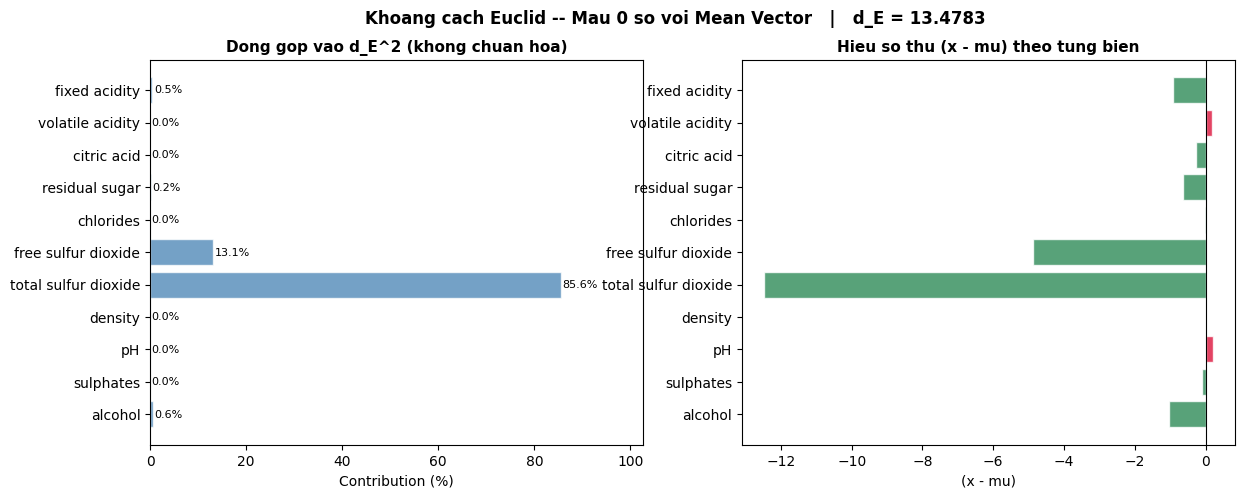

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart % dong gop
contribution_bar(sq_diff, var_list, f"Dong gop vao d_E^2 (khong chuan hoa)", color="steelblue", ax=axes[0])

# Hieu so thu (x - mu)
colors_bar = ["crimson" if v > 0 else "seagreen" for v in raw_diff]
axes[1].barh(var_list[::-1], raw_diff[::-1],
             color=colors_bar[::-1], alpha=0.8, edgecolor="white")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("(x - mu)", fontsize=10)
axes[1].set_title("Hieu so thu (x - mu) theo tung bien", fontsize=11, fontweight="bold")

plt.suptitle(f"Khoang cach Euclid -- Mau 0 so voi Mean Vector   |   d_E = {d_euclidean:.4f}",
             fontsize=12, fontweight="bold")
plt.show()

### Phân tích kết quả khoảng cách Euclid

**Quan sát từ biểu đồ đóng góp %:**

- **`total sulfur dioxide`** chiếm **≈ 85%** tổng $d_E^2$, mặc dù sự lệch
  $(x_0 - \hat{\mu}) \approx -12.5$ không hẳn là bất thường nhất về mặt thống kê.
  Nguyên nhân là đơn vị đo lớn → bình phương lớn.

- **`density`** (CV < 0.2 %) và **`volatile acidity`** dù có thể bất thường nhưng
  đóng góp gần như bằng 0 vào $d_E$.

**Hạn chế:**

| Vấn đề | Giải thích |
|--------|-----------|
| Nhạy thang đo | Biến có giá trị tuyệt đối lớn luôn chiếm ưu thế rất cao |
| Bỏ qua tương quan | Coi 11 chiều hoàn toàn độc lập |
| Không scale-invariant | Đổi đơn vị $mg/L → g/L$ → kết quả thay đổi |

> **Kết luận:** Euclid Distance chỉ hợp lệ khi các biến đã được chuẩn hóa về cùng thang đo.
> Trong Wine Quality, điều này không thỏa mãn.


### c. Statistical Distance

**Chuẩn hóa từng chiều:**
$$d_S(P, Q) = \sqrt{\sum_{k=1}^{p} \frac{(x_k - y_k)^2}{s_{kk}}}$$

**Dạng tổng quát:**
$$d(P, Q) = \sqrt{(P - Q)^\top A\, (P - Q)}$$



In [8]:
# Tính khoảng cách Statistical cho 1 sample trong dữ liệu
# Chuẩn hóa mỗi chiều theo phương sai 
d_S  = statistical_distance(sample_0, ref_mean, sample_var)
print(f"Khoảng cách thống kê đơn giản: d_S(p, mean) = {d_S:.4f}")
print()

# Đóng góp từng biến vào khoảng cách thống kê
sq_diff_S = (raw_diff ** 2) / sample_var
pct_S = sq_diff_S / np.sum(sq_diff_S) * 100
z_scores = raw_diff / sample_std

contrib_statistical = pd.DataFrame({
    "x - mu": raw_diff,
    "sigma": sample_std,
    "z = (x - mu) / sigma": z_scores,
    "sq_diff_S": sq_diff_S,
    "pct_S": pct_S
}, index=var_list).round(2)

print("Đóng góp của từng biến vào khoảng cách statistical (sau chuẩn hóa):")
print(contrib_statistical.to_string())

Khoảng cách thống kê đơn giản: d_S(p, mean) = 2.6450

Đóng góp của từng biến vào khoảng cách statistical (sau chuẩn hóa):
                      x - mu  sigma  z = (x - mu) / sigma  sq_diff_S  pct_S
fixed acidity          -0.92   1.74                 -0.53       0.28   3.99
volatile acidity        0.17   0.18                  0.96       0.93  13.22
citric acid            -0.27   0.19                 -1.39       1.94  27.67
residual sugar         -0.64   1.41                 -0.45       0.21   2.94
chlorides              -0.01   0.05                 -0.24       0.06   0.85
free sulfur dioxide    -4.87  10.46                 -0.47       0.22   3.11
total sulfur dioxide  -12.47  32.89                 -0.38       0.14   2.05
density                 0.00   0.00                  0.56       0.31   4.45
pH                      0.20   0.15                  1.29       1.66  23.74
sulphates              -0.10   0.17                 -0.58       0.34   4.80
alcohol                -1.02   1.07       

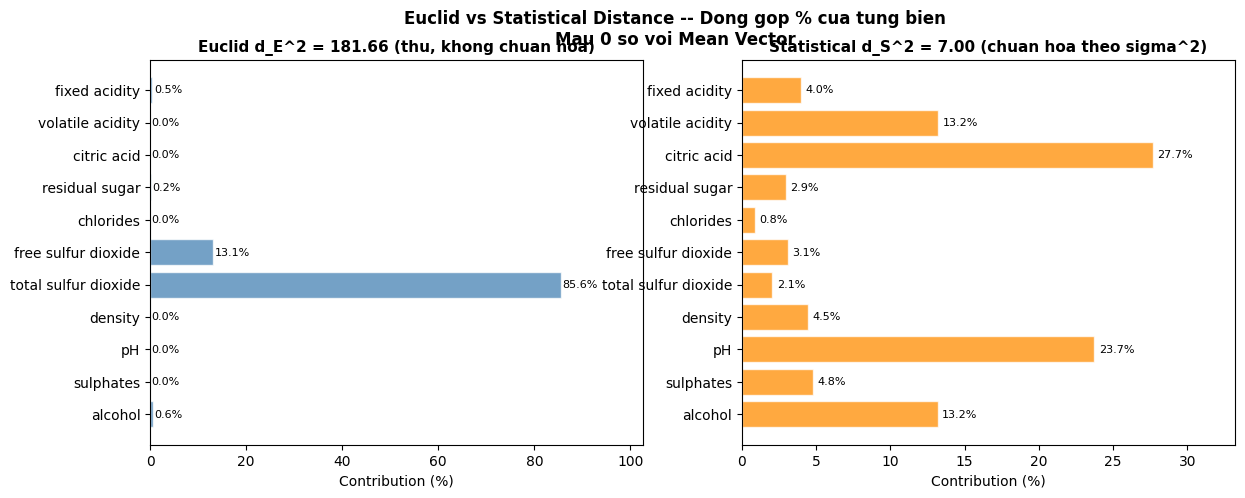

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contribution_bar(sq_diff, var_list,
                 f"Euclid d_E^2 = {d_euclidean**2:.2f} (thu, khong chuan hoa)",
                 color="steelblue", ax=axes[0])

contribution_bar(sq_diff_S, var_list,
                 f"Statistical d_S^2 = {d_S**2:.2f} (chuan hoa theo sigma^2)",
                 color="darkorange", ax=axes[1])

plt.suptitle("Euclid vs Statistical Distance -- Dong gop % cua tung bien\n"
             "Mau 0 so voi Mean Vector", fontsize=12, fontweight="bold")
plt.show()


### Phân tích kết quả Statistical Distance

**So sánh hai biểu đồ giữa Euclid distance và Statistical Distance:**

| Biến | $d_E^2$ (thô) | $d_S^2$ (chuẩn hóa) 
|------|:-:|:-:|
| `total sulfur dioxide` | **85.6 %** | ≈ 2 % | 
| `citric acid` | < 1 % | **≈ 28 %** | 
| `pH` | < 1 % | **≈ 24 %** | 
| `volatile acidity` | < 1 % | ≈ 13 % | 

**Giải thích bằng z-score:**
Sau chuẩn hóa, $d_S^2 = \sum_k z_k^2$, tức là tổng bình phương z-score.
Biến nào có $z$ lớn nhất → đóng góp nhiều nhất → phản ánh đúng độ bất thường.

**Hạn chế còn lại:**
$d_S$ vẫn **giả định các biến độc lập** (ma trận $A$ chỉ có đường chéo).
Với Wine Quality, `fixed acidity` ↔ `pH` có $r = -0.68$ → Statistical Distance đo sai biệt thông tin giữa các biến, ngay cả khi chúng có tương quan tuyến tính mạnh. 


### c. Mahalanobis Distance 

$$d_M^2(\mathbf{x}_j, \bar{\mathbf{x}}) = (\mathbf{x}_j - \bar{\mathbf{x}})^\top S^{-1} (\mathbf{x}_j - \bar{\mathbf{x}})$$

$S^{-1}$ là nghịch đảo **ma trận hiệp phương sai mẫu** — mã hóa đầy đủ cả
(1) phương sai từng chiều và (2) tương quan giữa các cặp biến.


In [10]:
# Khoảng cách Mahalanobis
# Tính d_M cho mẫu đầu tiên

import math

X = features.values.astype(float)
mu_hat = X.mean(axis=0) # ước lượng mu 
cov_matrix = np.cov(X, rowvar=False)

d_M_0 = mahalanobis_distance(sample_0, mu_hat, cov_matrix)
D2_0 = d_M_0 ** 2

print(f"Khoảng cách Mahalanobis của mẫu 0 so với ước lượng trung bình quần thể: d_M = {d_M_0:.4f}")
print()
print("So sánh khoảng cách Mahalanobis với Euclid và Statistical:")
print(f"Euclid d_E = {d_euclidean:.4f}")
print(f"Statistical d_S = {d_S:.4f}")
print(f"Mahalanobis d_M = {d_M_0:.4f}")

Khoảng cách Mahalanobis của mẫu 0 so với ước lượng trung bình quần thể: d_M = 2.2181

So sánh khoảng cách Mahalanobis với Euclid và Statistical:
Euclid d_E = 13.4783
Statistical d_S = 2.6450
Mahalanobis d_M = 2.2181


In [11]:
# Tính D^2 cho tất cả mẫu
D_all = np.array([mahalanobis_distance(x, mu_hat, cov_matrix) for x in X])
D2_all = D_all ** 2

# Ngưỡng chi-square, p bậc tự do, alpha = 0.025
p_dim = X.shape[1]
chi2_threshold = stats.chi2.ppf(0.975, df=p_dim)

outliers_mask = D2_all > chi2_threshold
n_outliers = outliers_mask.sum()

print(f"p = {p_dim} bien")
print(f"Ngưỡng chi-square (alpha=0.025): {chi2_threshold:.2f}")
print(f"Số mẫu vượt ngưỡng (có thể là outliers): {n_outliers} / {len(X)}")
print(f"Tỷ lệ mẫu vượt ngưỡng: {n_outliers / len(X) * 100:.2f}%")


p = 11 bien
Ngưỡng chi-square (alpha=0.025): 21.92
Số mẫu vượt ngưỡng (có thể là outliers): 125 / 1599
Tỷ lệ mẫu vượt ngưỡng: 7.82%


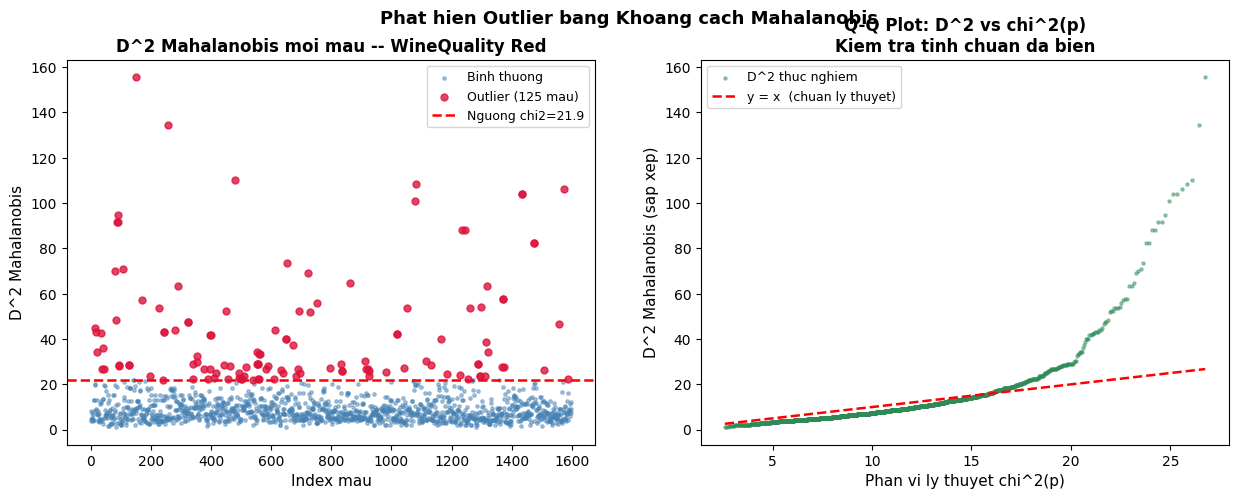

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Bieu do 1: D^2 theo index mau ---
ax1 = axes[0]
ax1.scatter(np.where(~outliers_mask)[0], D2_all[~outliers_mask],
            s=6, color="steelblue", alpha=0.45, label="Binh thuong")
ax1.scatter(np.where(outliers_mask)[0], D2_all[outliers_mask],
            s=25, color="crimson", alpha=0.8, zorder=3,
            label=f"Outlier ({n_outliers} mau)")
ax1.axhline(chi2_threshold, color="red", lw=1.8, ls="--",
            label=f"Nguong chi2={chi2_threshold:.1f}")
ax1.set_xlabel("Index mau", fontsize=11)
ax1.set_ylabel("D^2 Mahalanobis", fontsize=11)
ax1.set_title("D^2 Mahalanobis moi mau -- WineQuality Red", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9)

# --- Bieu do 2: Q-Q plot D^2 vs chi^2(p) ---
ax2 = axes[1]
sorted_D2      = np.sort(D2_all)
n_pts          = len(sorted_D2)
chi2_quantiles = stats.chi2.ppf(np.linspace(0.005, 0.995, n_pts), df=p_dim)

ax2.scatter(chi2_quantiles, sorted_D2, s=5, alpha=0.45, color="seagreen",
            label="D^2 thuc nghiem")
ax2.plot([chi2_quantiles[0], chi2_quantiles[-1]],
         [chi2_quantiles[0], chi2_quantiles[-1]],
         "r--", lw=1.8, label="y = x  (chuan ly thuyet)")
ax2.set_xlabel("Phan vi ly thuyet chi^2(p)", fontsize=11)
ax2.set_ylabel("D^2 Mahalanobis (sap xep)", fontsize=11)
ax2.set_title("Q-Q Plot: D^2 vs chi^2(p)\nKiem tra tinh chuan da bien", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle("Phat hien Outlier bang Khoang cach Mahalanobis", fontsize=13, fontweight="bold")
plt.show()


### Phân tích kết quả Mahalanobis Distance

#### Biểu đồ 1 — D² theo index mẫu

Biểu đồ này biểu diễn giá trị bình phương khoảng cách Mahalanobis cho từng mẫu dữ liệu.

- **Vùng bình thường:** trung vị $D^2 \approx 7.7 \ll 21.9$ → phần lõi dữ liệu tốt.
- **Outlier (125 mẫu, 7.8 %):** phân tán rải rác theo toàn bộ chỉ số — không tập trung ở một vùng cụ thể.
- **Điểm cực đoan:** $D^2_{\max} \approx 155.5$ — vi phạm đồng thời nhiều chiều trong không gian hiệp phương sai.

#### Biểu đồ 2 — Q-Q Plot D² vs χ²(p)

Biểu đồ Q-Q dùng để đánh giá mức độ phù hợp của dữ liệu thực nghiệm với giả thuyết chuẩn đa biến

- **Đoạn 0 - 15:** bám khá sát đường $y=x$ → **phần lõi gần chuẩn đa biến**.
- **Đoạn 20 - 25:** các điểm thực nghiệm bắt đầu tách rời đường lý thuyết và dốc lên nhanh chóng → **heavy-tailed distribution** .
- **Hệ quả:** ngưỡng $\chi^2_{0.975}$ có thể ước lượng thấp số outlier thực nếu heavy tail nghiêm trọng hơn.


### d. So sánh 3 Độ đo 

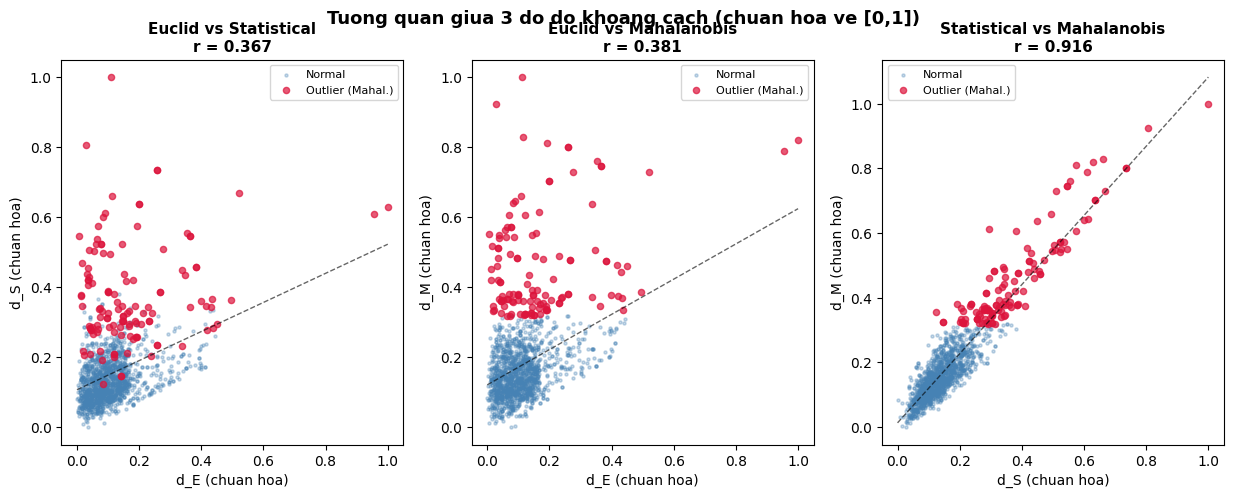

In [13]:
# Tinh 3 do do cho toan bo dataset
d_E_all = np.sqrt(np.sum((X - mu_hat) ** 2, axis=1))
d_S_all = np.sqrt(np.sum((X - mu_hat) ** 2 / sample_var, axis=1))
d_M_all = D_all.copy()

# Chuan hoa ve [0, 1] de so sanh truc quan
def norm01(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

de_n = norm01(d_E_all)
ds_n = norm01(d_S_all)
dm_n = norm01(d_M_all)

# Scatter matrix 3 do do
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [
    (de_n, ds_n, "d_E (chuan hoa)", "d_S (chuan hoa)", "Euclid vs Statistical"),
    (de_n, dm_n, "d_E (chuan hoa)", "d_M (chuan hoa)", "Euclid vs Mahalanobis"),
    (ds_n, dm_n, "d_S (chuan hoa)", "d_M (chuan hoa)", "Statistical vs Mahalanobis"),
]

for ax, (x_arr, y_arr, xl, yl, title) in zip(axes, pairs):
    ax.scatter(x_arr[~outliers_mask], y_arr[~outliers_mask],
               s=5, alpha=0.3, color="steelblue", label="Normal")
    ax.scatter(x_arr[outliers_mask],  y_arr[outliers_mask],
               s=20, alpha=0.7, color="crimson", label="Outlier (Mahal.)")
    z   = np.polyfit(x_arr, y_arr, 1)
    xr  = np.linspace(0, 1, 100)
    ax.plot(xr, np.poly1d(z)(xr), "k--", lw=1, alpha=0.6)
    r = np.corrcoef(x_arr, y_arr)[0, 1]
    ax.set_xlabel(xl, fontsize=10)
    ax.set_ylabel(yl, fontsize=10)
    ax.set_title(f"{title}\nr = {r:.3f}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Tuong quan giua 3 do do khoang cach (chuan hoa ve [0,1])",
             fontsize=13, fontweight="bold")
plt.show()


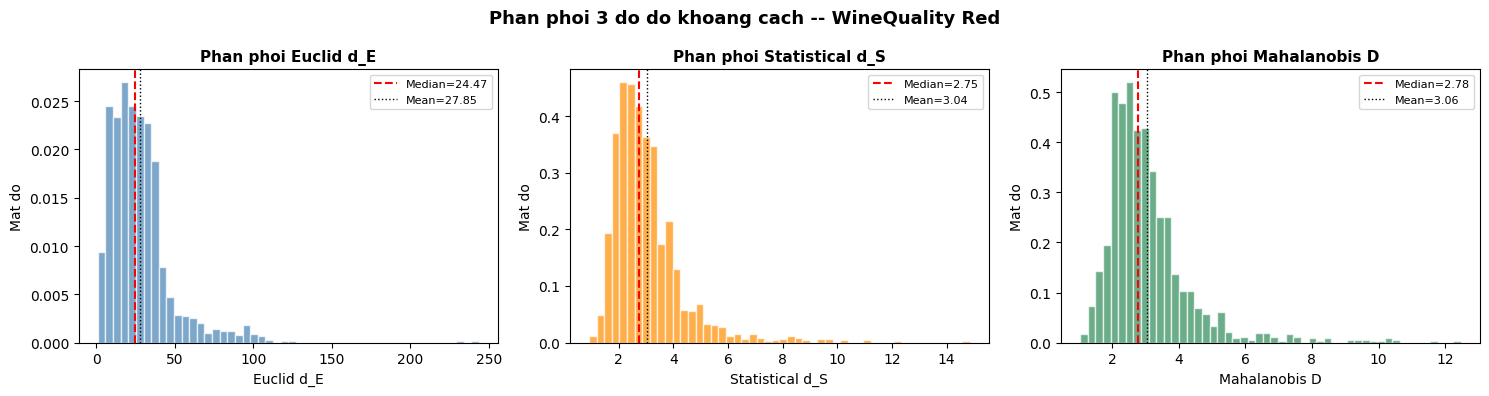

In [14]:
# Histogram phan phoi 3 do do
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (arr, label, color) in zip(axes, [
        (d_E_all, "Euclid d_E",      "steelblue"),
        (d_S_all, "Statistical d_S", "darkorange"),
        (d_M_all, "Mahalanobis D",   "seagreen")]):
    ax.hist(arr, bins=50, color=color, alpha=0.7, edgecolor="white", density=True)
    ax.axvline(np.median(arr), color="red",   lw=1.5, ls="--", label=f"Median={np.median(arr):.2f}")
    ax.axvline(np.mean(arr),   color="black", lw=1.0, ls=":",  label=f"Mean={np.mean(arr):.2f}")
    ax.set_xlabel(f"{label}", fontsize=10); ax.set_ylabel("Mat do", fontsize=10)
    ax.set_title(f"Phan phoi {label}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Phan phoi 3 do do khoang cach -- WineQuality Red", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Phân tích so sánh 3 độ đo

#### Tương quan giữa các cặp

| Cặp | r | Nhận xét |
|-----|:-:|---------|
| $d_E$ vs $d_S$ | ≈ 0.37 | Độ tương quan thấp. Các điểm dữ liệu (đặc biệt là các điểm đỏ) phân tán rất rộng, không bám theo đường chéo. |
| $d_E$ vs $D$ | ≈ 0.38 | Euclid Distance bỏ qua hiệp phương sai, dẫn đến sự sai lệch lớn khi xác định vị trí tương đối của dữ liệu. |
| $d_S$ vs $D$ | ≈ 0.92 | Độ tương quan rất mạnh. Các điểm dữ liệu bám sát đường chéo tuyến tính. |

* Khoảng cách Euclid dễ dàng bỏ sót các điểm dị biệt đa biến vì nó chỉ đo lường độ dài vật lý mà không tính đến sự biến thiên nội tại của quần thể.
* Khoảng cách Mahalanobis là thước đo nhạy bén nhất để nhận diện các điểm dữ liệu lệch về mặt cấu trúc. Nếu chỉ dựa vào $d_E$ hoặc các biến thể đơn giản của $d_S$, một lượng lớn dữ liệu bất thường sẽ bị bỏ qua.

#### Phân phối

| Độ đo | Đặc điểm | Nguyên nhân |
|-------|----------|-----------|
| $d_E$ | Dải giá trị rất rộng (0 - 250). Bị kéo giãn mạnh bởi các điểm có giá trị tuyệt đối lớn. | `total SO₂` khuếch đại |
| $d_S$ | Dải giá trị hẹp, tập trung (1 - 14). Hình thái phân phối tương đồng | Chuẩn hóa loại ảnh hưởng thang đo |
| $d_M$ | Phân phối lệch phải rõ rệt, nhận diện tốt Outliers. Chỉ số Mean và Median xấp xỉ (~2.78 và ~3.06). | Tính đến hiệp phương sai - mối tương quan giữa các biến |


### e. Phát hiện Outlier

### e.1 Z-score — Outlier đơn biến

$$z_{jk} = \frac{x_{jk} - \hat{\mu}_k}{\hat{s}_k}, \quad |z| > 3 \Rightarrow \text{outlier đơn biến}$$


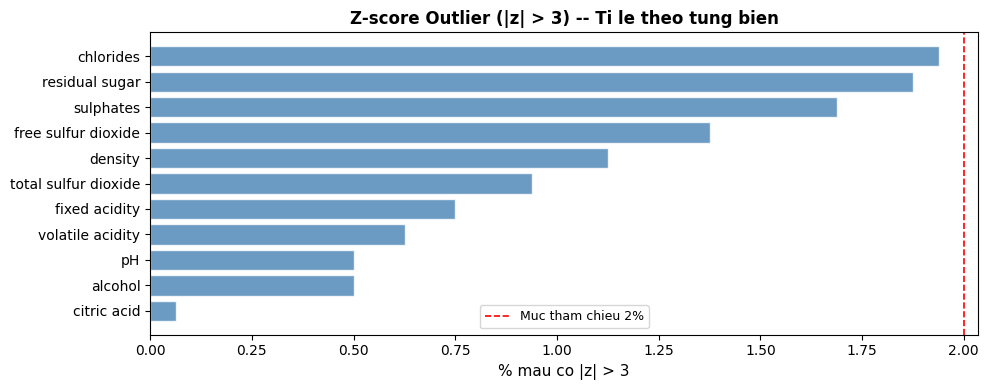

Ti le % mau co |z| > 3:
  chlorides                    1.9%  =========
  residual sugar               1.9%  =========
  sulphates                    1.7%  ========
  free sulfur dioxide          1.4%  ======
  density                      1.1%  =====
  total sulfur dioxide         0.9%  ====
  fixed acidity                0.8%  ===
  volatile acidity             0.6%  ===
  pH                           0.5%  ==
  alcohol                      0.5%  ==
  citric acid                  0.1%  


In [15]:
# Z-score toan dataset (dung sample std ddof=1)
Z_all = (X - mu_hat) / sample_std
Z_df  = pd.DataFrame(Z_all, columns=var_list)

zscore_pct = {c: (abs(Z_df[c]) > 3).mean() * 100 for c in var_list}
zscore_ser = pd.Series(zscore_pct).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors_z = ["crimson" if v > 2 else "steelblue" for v in zscore_ser.values]
ax.barh(zscore_ser.index[::-1], zscore_ser.values[::-1],
        color=colors_z[::-1], alpha=0.8, edgecolor="white")
ax.axvline(2, color="red", ls="--", lw=1.2, label="Muc tham chieu 2%")
ax.set_xlabel("% mau co |z| > 3", fontsize=11)
ax.set_title("Z-score Outlier (|z| > 3) -- Ti le theo tung bien", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Ti le % mau co |z| > 3:")
for c, pct in zscore_ser.items():
    bar = "=" * int(pct * 5)
    print(f"  {c:28s} {pct:.1f}%  {bar}")


### Phân tích Z-score

- **`residual sugar`** và **`chlorides`** dẫn đầu (≈ 1.9 % mỗi biến)
  → phân phối đuôi phải dài.
- **`citric acid`** thấp nhất (≈ 0.1 %) — dù nhiều mẫu có giá trị 0,
  $\hat{\mu} \approx 0.27$, $\hat{s} \approx 0.19$ nên z-score vẫn trong ngưỡng.

**Hạn chế quan trọng của Z-score:**

Z-score xét **từng biến độc lập**. Một mẫu có thể bình thường trên mỗi biến đơn nhưng bất thường khi kết hợp các biến.

Ví dụ: `fixed acidity` cao bất thường kết hợp với `pH` cao bất thường là mâu thuẫn (do $r = -0.68$) → outlier đa biến mà z-score không phát hiện.


### e.2 Top Outliers theo Mahalanobis

In [16]:
outlier_df = features[outliers_mask].copy()
outlier_df["D2_Mahal"]  = D2_all[outliers_mask]
outlier_df["D_Mahal"]   = D_all[outliers_mask]
outlier_df["quality"]   = df.loc[outliers_mask, "quality"].values
outlier_df = outlier_df.sort_values("D2_Mahal", ascending=False)

print(f"Tong so outlier (D^2 > {chi2_threshold:.2f}): {n_outliers}")
print()
cols = ["fixed acidity", "volatile acidity", "citric acid",
        "total sulfur dioxide", "alcohol", "D2_Mahal", "D_Mahal", "quality"]
print("Top 10 outliers (theo D^2):")
print(outlier_df[cols].head(10).round(4).to_string())


Tong so outlier (D^2 > 21.92): 125

Top 10 outliers (theo D^2):
      fixed acidity  volatile acidity  citric acid  total sulfur dioxide  alcohol  D2_Mahal  D_Mahal  quality
151             9.2              0.52         1.00                  69.0      9.4  155.5464  12.4718        4
258             7.7              0.41         0.76                  45.0      9.4  134.5464  11.5994        5
480            10.6              0.28         0.39                  23.0      9.2  110.2623  10.5006        5
1081            7.9              0.30         0.68                 289.0     12.3  108.6136  10.4218        7
1574            5.6              0.31         0.78                  92.0     10.5  106.3418  10.3122        6
1434           10.2              0.54         0.37                  95.0      9.0  103.9819  10.1971        6
1435           10.2              0.54         0.37                  95.0      9.0  103.9819  10.1971        6
1079            7.9              0.30         0.68      

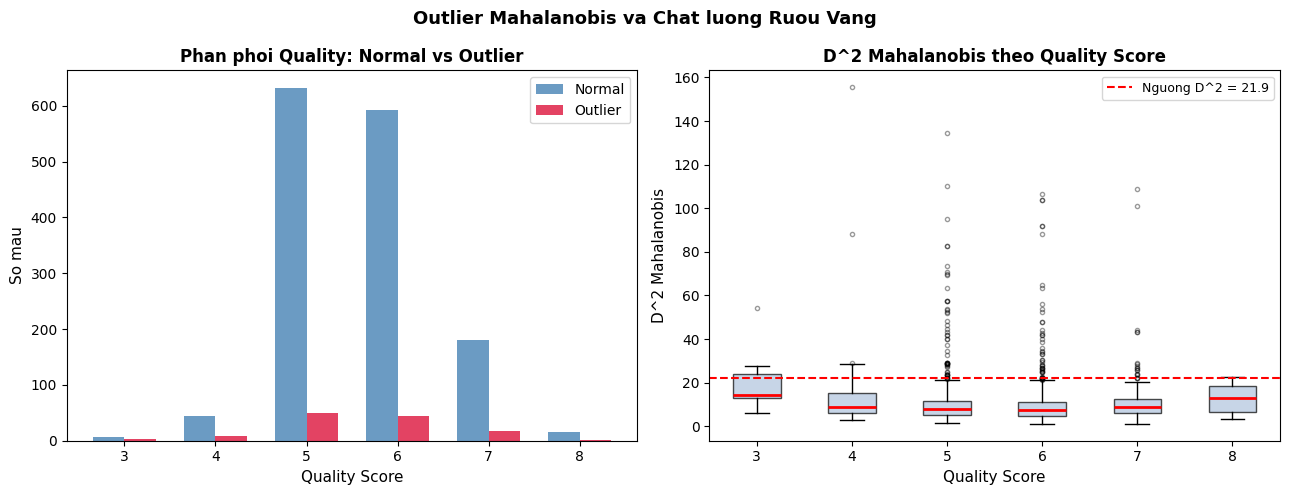

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar: quality phan phoi
ax1 = axes[0]
qs = sorted(df["quality"].unique())
normal_q  = df.loc[~outliers_mask, "quality"]
outlier_q = df.loc[outliers_mask,  "quality"]
nc = [normal_q.value_counts().get(q, 0)  for q in qs]
oc = [outlier_q.value_counts().get(q, 0) for q in qs]
w = 0.35
xp = np.arange(len(qs))
ax1.bar(xp - w/2, nc, w, label="Normal",  color="steelblue", alpha=0.8)
ax1.bar(xp + w/2, oc, w, label="Outlier", color="crimson",   alpha=0.8)
ax1.set_xticks(xp); ax1.set_xticklabels(qs)
ax1.set_xlabel("Quality Score", fontsize=11); ax1.set_ylabel("So mau", fontsize=11)
ax1.set_title("Phan phoi Quality: Normal vs Outlier", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)

# Boxplot D^2 theo quality
ax2 = axes[1]
for q in qs:
    vals = D2_all[df["quality"] == q]
    ax2.boxplot(vals, positions=[q], widths=0.5, patch_artist=True,
                boxprops=dict(facecolor="lightsteelblue", alpha=0.7),
                medianprops=dict(color="red", lw=2),
                flierprops=dict(marker="o", markersize=3, alpha=0.4))
ax2.axhline(chi2_threshold, color="red", ls="--", lw=1.5,
            label=f"Nguong D^2 = {chi2_threshold:.1f}")
ax2.set_xlabel("Quality Score", fontsize=11)
ax2.set_ylabel("D^2 Mahalanobis", fontsize=11)
ax2.set_title("D^2 Mahalanobis theo Quality Score", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle("Outlier Mahalanobis va Chat luong Ruou Vang", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Phân tích Outlier & Quality

- **Quality 3 & 8** có **median D² cao hơn** các nhóm trung bình
  → rượu rất tốt hoặc rất xấu có cấu trúc hóa học bất thường hơn.
- **Quality 5–6** nhiều outlier nhất về số lượng — nhưng đây cũng là hai nhóm đông nhất (> 80 % dataset).
- Nhiều outlier Mahalanobis **không phải rượu xấu** — chỉ là tổ hợp hóa học bất thường,
  ví dụ: `fixed acidity` cao kết hợp `pH` cao (mâu thuẫn do tương quan âm).
